In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Импортируем твои алгоритмы (убедись, что __init__.py есть в папке algos, 
# либо просто добавь путь в sys.path)
from algos import fuzzy, oracle, broumi, moghanni, montemanni, xu

# Настройка визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8') # или другой стиль по вкусу

print("Окружение готово к работе!")

Окружение готово к работе!


In [41]:
# Посмотрим список файлов в датасете
dataset_path = 'dataset/'
files = os.listdir(dataset_path)
print(f"Файлы в датасете: {files}")

# Давай загрузим один для примера (замени 'example.csv' на реальное имя файла)
df_sample = pd.read_csv(os.path.join(dataset_path, files[0]))
df_sample.head()

Файлы в датасете: ['graph_0001_n43.txt', 'graph_0002_n20.txt', 'graph_0003_n9.txt', 'graph_0004_n74.txt', 'graph_0005_n85.txt', 'graph_0006_n98.txt', 'graph_0007_n3.txt', 'graph_0008_n58.txt', 'graph_0009_n17.txt', 'graph_0010_n61.txt', 'graph_0011_n80.txt', 'graph_0012_n64.txt', 'graph_0013_n48.txt', 'graph_0014_n39.txt', 'graph_0015_n91.txt', 'graph_0016_n65.txt', 'graph_0017_n44.txt', 'graph_0018_n51.txt', 'graph_0019_n24.txt', 'graph_0020_n19.txt', 'graph_0021_n9.txt', 'graph_0022_n6.txt', 'graph_0023_n84.txt', 'graph_0024_n45.txt', 'graph_0025_n39.txt', 'graph_0026_n69.txt', 'graph_0027_n49.txt', 'graph_0028_n66.txt', 'graph_0029_n25.txt', 'graph_0030_n98.txt', 'graph_0031_n56.txt', 'graph_0032_n55.txt', 'graph_0033_n95.txt', 'graph_0034_n33.txt', 'graph_0035_n94.txt', 'graph_0036_n86.txt', 'graph_0037_n94.txt', 'graph_0038_n46.txt', 'graph_0039_n4.txt', 'graph_0040_n66.txt', 'graph_0041_n33.txt', 'graph_0042_n87.txt', 'graph_0043_n33.txt', 'graph_0044_n33.txt', 'graph_0045_n83.tx

,43 99
0,0 13 60 61 61
1,0 37 81 94 93
2,0 21 80 89 82
3,0 6 47 67 66
4,13 8 78 98 91


In [42]:
import glob
import os
import pandas as pd

results_path = 'results/'
all_files = glob.glob(os.path.join(results_path, "*.csv"))

# Читаем первый файл
main_df = pd.read_csv(all_files[0])

def clean_columns(df, file_name):
    # Извлекаем чистое имя алгоритма из названия файла
    alg_name = os.path.basename(file_name).replace('_results.csv', '').replace('_costs.csv', '')
    
    new_cols = {}
    for col in df.columns:
        if col == 'graph_file':
            continue
            
        # Убираем повторы, если имя алгоритма уже есть в названии колонки
        clean_col = col.replace(f"{alg_name}_", "")
        new_cols[col] = f"{alg_name}_{clean_col}"
        
    return df.rename(columns=new_cols)

# Обрабатываем первый файл
main_df = clean_columns(main_df, all_files[0])

# Присоединяем остальные
for file in all_files[1:]:
    current_df = pd.read_csv(file)
    current_df = clean_columns(current_df, file)
    
    # Объединяем по graph_file
    main_df = pd.merge(main_df, current_df, on='graph_file', how='inner')

# Выводим список колонок, чтобы убедиться, что всё красиво
print("Список колонок после объединения:")
print(main_df.columns.tolist())
main_df.head()

Список колонок после объединения:
['graph_file', 'broumi_execution_time_ms', 'broumi_cost_real', 'broumi_path_length', 'fuzzy_execution_time_ms', 'fuzzy_cost_real', 'fuzzy_path_length', 'moghanni_execution_time_ms', 'moghanni_cost_real', 'moghanni_path_length', 'montemanni_execution_time_ms', 'montemanni_cost_real', 'montemanni_path_length', 'oracle_num_nodes', 'oracle_ideal_cost_real', 'oracle_ideal_path_length', 'xu_execution_time_ms', 'xu_cost_real', 'xu_path_length']


,graph_file,broumi_execution_time_ms,broumi_cost_real,broumi_path_length,fuzzy_execution_time_ms,fuzzy_cost_real,fuzzy_path_length,moghanni_execution_time_ms,moghanni_cost_real,moghanni_path_length,montemanni_execution_time_ms,montemanni_cost_real,montemanni_path_length,oracle_num_nodes,oracle_ideal_cost_real,oracle_ideal_path_length,xu_execution_time_ms,xu_cost_real,xu_path_length
0,graph_0001_n43.txt,0.1285,198,3,0.0653,198,3,0.1785,198,3,9.0289,198.0,3,43,198,3,0.0975,198,3
1,graph_0002_n20.txt,0.0129,59,1,0.0092,59,1,0.0119,59,1,6.3377,59.0,1,20,59,1,0.0138,59,1
2,graph_0003_n9.txt,0.0091,53,1,0.0077,53,1,0.0222,53,1,4.1309,53.0,1,9,53,1,0.0072,53,1
3,graph_0004_n74.txt,0.0203,111,2,0.0125,111,2,0.0176,111,2,13.0102,111.0,2,74,111,2,0.0120,111,2
4,graph_0005_n85.txt,0.0174,70,1,0.0055,70,1,0.0083,70,1,10.3935,70.0,1,85,70,1,0.0044,70,1


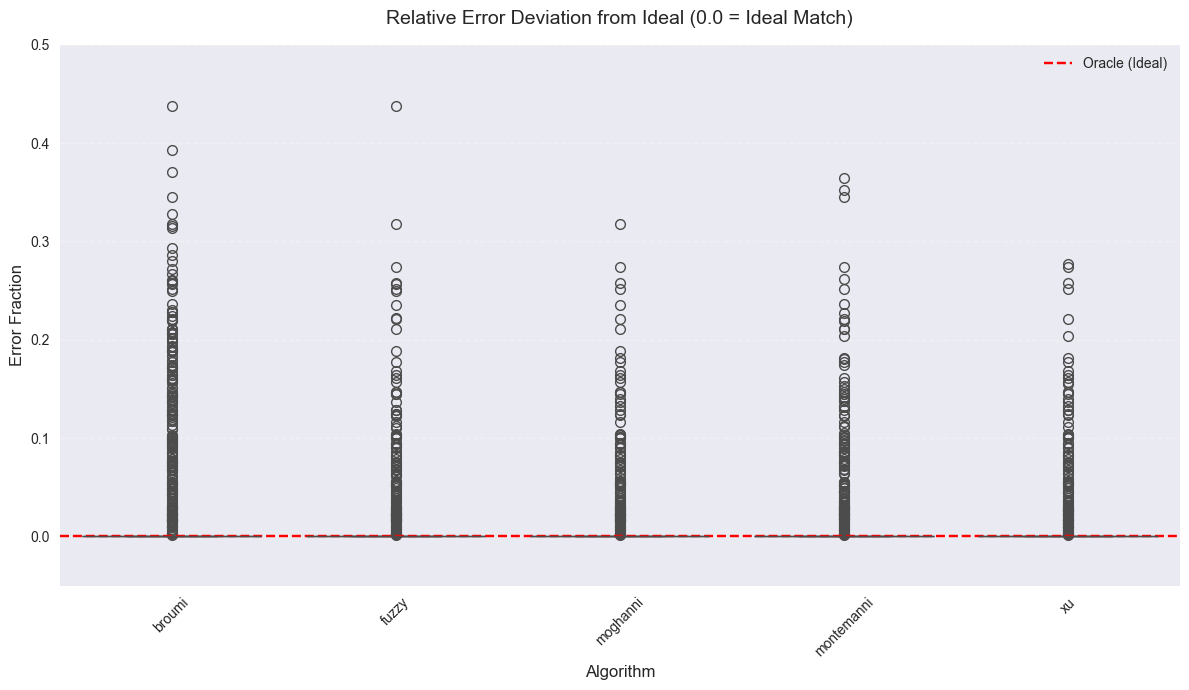

In [43]:
# 1. Calculate relative error for each algorithm
oracle_col = 'oracle_ideal_cost_real'
error_df = pd.DataFrame()

# Select cost columns, excluding the oracle itself
cost_cols = [col for col in main_df.columns if 'cost_real' in col and col != oracle_col]

for col in cost_cols:
    # Capitalize algorithm name for consistency
    alg_name = col.replace('_cost_real', '').lower()
    # Relative Error formula: (Algorithm - Oracle) / Oracle
    error_df[alg_name] = (main_df[col] - main_df[oracle_col]) / main_df[oracle_col]

# 2. Build Boxplot for errors (limiting y-axis to handle outliers)
plt.figure(figsize=(12, 7))
sns.boxplot(data=error_df)

# Setting limits to show deviations from -5% to +50% clearly
plt.ylim(-0.05, 0.5) 
plt.axhline(y=0, color='r', linestyle='--', label='Oracle (Ideal)')

# English titles and labels
plt.title("Relative Error Deviation from Ideal (0.0 = Ideal Match)", fontsize=14, pad=15)
plt.ylabel("Error Fraction", fontsize=12)
plt.xlabel("Algorithm", fontsize=12)

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

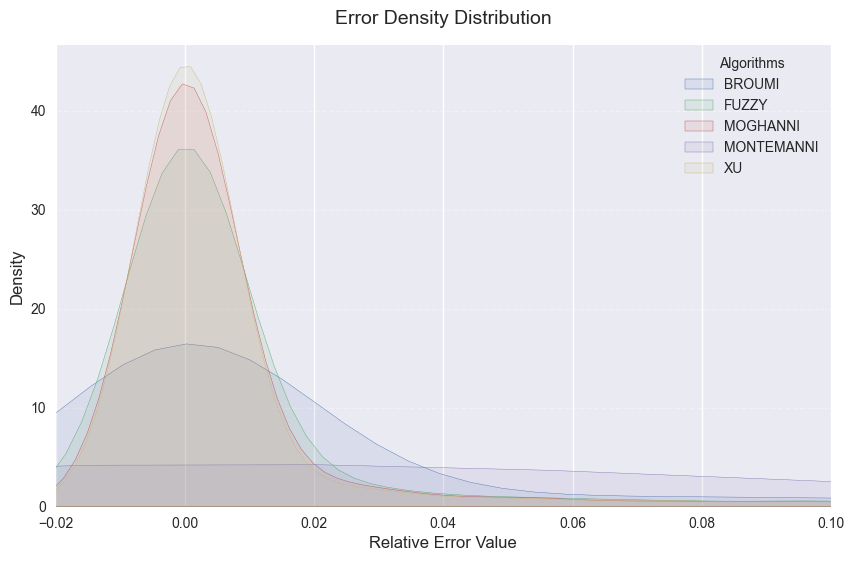

In [44]:
plt.figure(figsize=(10, 6))

for col in error_df.columns:
    # Plotting the error density distribution
    # Capitalizing the column name for a cleaner legend
    sns.kdeplot(error_df[col], label=col.upper(), fill=True, alpha=0.1)

# Focus on the low-error zone (0% to 10%) to see the differences between top algorithms
plt.xlim(-0.02, 0.1) 

# English labels and title
plt.title("Error Density Distribution", fontsize=14, pad=15)
plt.xlabel("Relative Error Value", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.legend(title="Algorithms")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

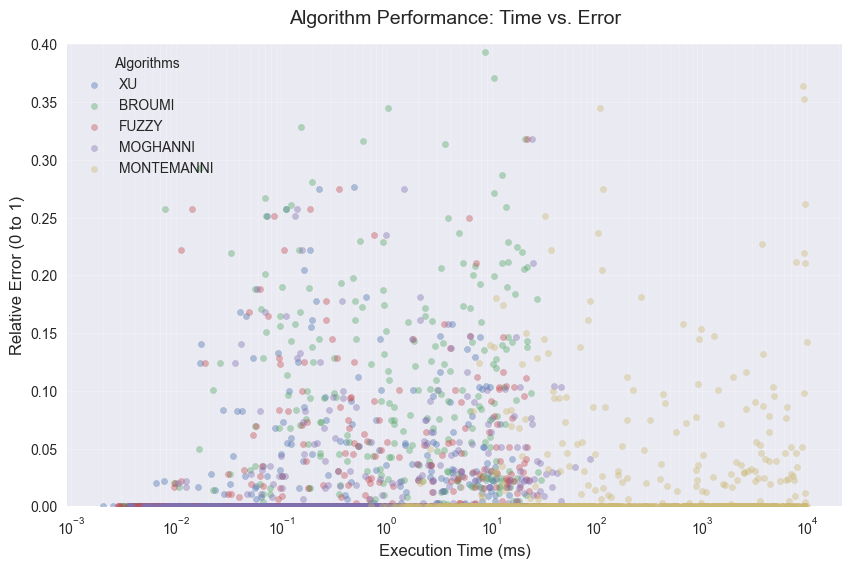

In [45]:
plt.figure(figsize=(10, 6))
algs = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']

for alg in algs:
    # Using the correct column name from your list
    time_col = f'{alg}_execution_time_ms'
    if time_col in main_df.columns:
        # Plotting with capitalized labels for the legend
        plt.scatter(main_df[time_col], error_df[alg], alpha=0.4, label=alg.upper(), s=20)

# Logarithmic scale is useful if time values span multiple orders of magnitude
plt.xscale('log') 

# English labels and title
plt.xlabel('Execution Time (ms)', fontsize=12)
plt.ylabel('Relative Error (0 to 1)', fontsize=12)
plt.title('Algorithm Performance: Time vs. Error', fontsize=14, pad=15)

# Focus on the low-error zone for better detail
plt.ylim(0, 0.4) 

plt.legend(title="Algorithms")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

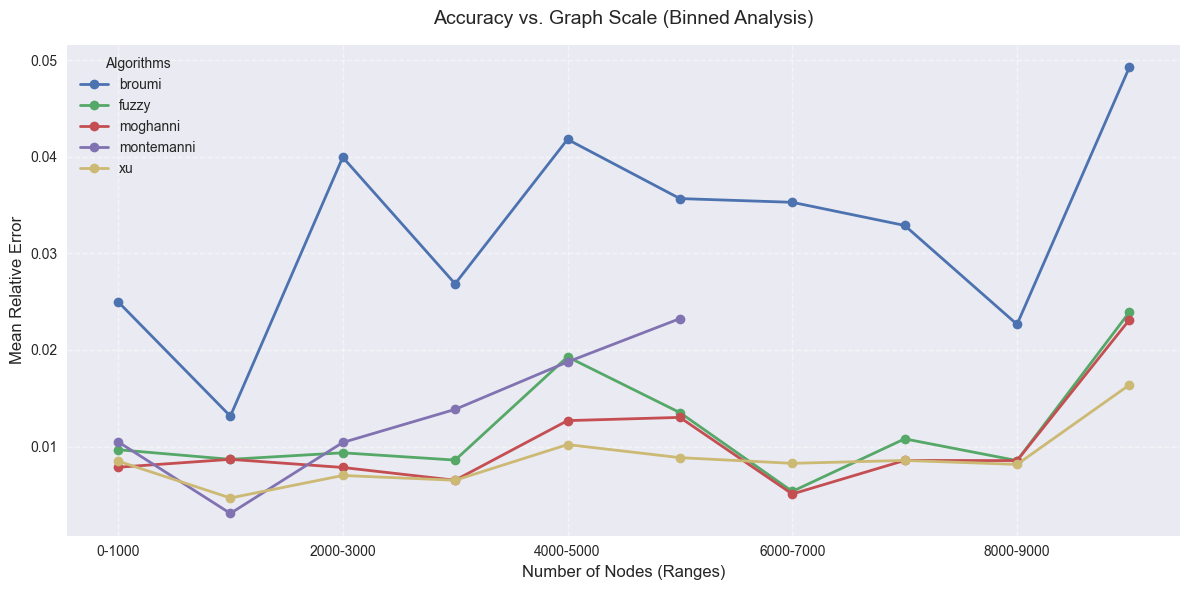

In [46]:
# 1. Create bins every 1000 nodes
main_df['node_range'] = pd.cut(main_df['oracle_num_nodes'], 
                               bins=range(0, 11000, 1000), 
                               labels=[f'{i}-{i+1000}' for i in range(0, 10000, 1000)])

# 2. Calculate mean error for each range
binned_error = error_df.copy()
binned_error['node_range'] = main_df['node_range']
# Grouping and calculating mean
plot_data = binned_error.groupby('node_range', observed=True).mean()

# 3. Visualization
plt.figure(figsize=(12, 6))
plot_data.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)

# English titles and labels
plt.title("Accuracy vs. Graph Scale (Binned Analysis)", fontsize=14, pad=15)
plt.xlabel("Number of Nodes (Ranges)", fontsize=12)
plt.ylabel("Mean Relative Error", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Algorithms")
plt.tight_layout()
plt.show()

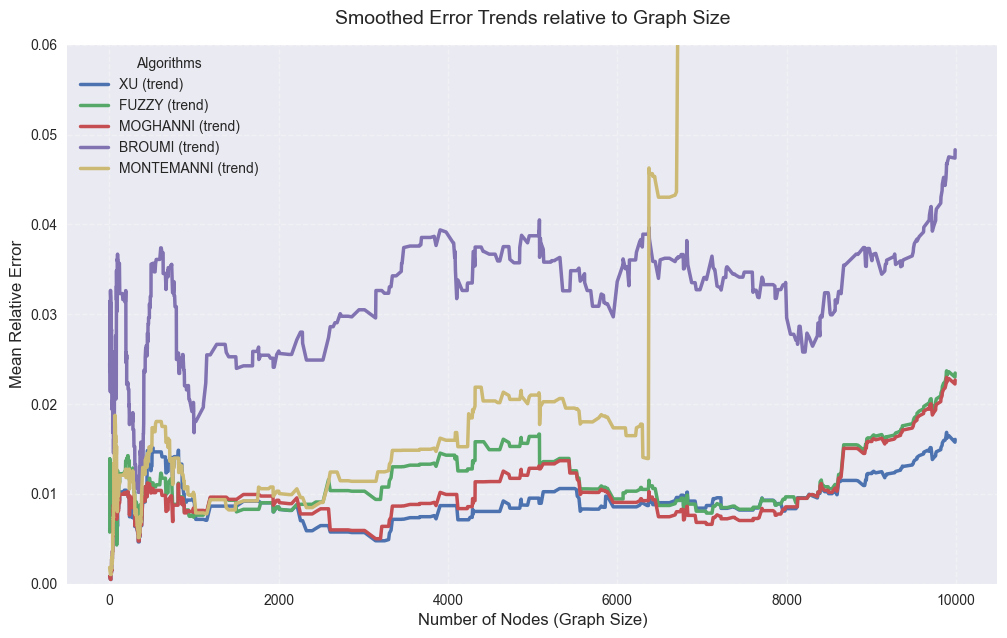

In [47]:
plt.figure(figsize=(12, 7))

# List of algorithms to compare
algs_to_compare = ['xu', 'fuzzy', 'moghanni', 'broumi', 'montemanni']

# Create a copy for sorting and trend analysis
trend_df = error_df[algs_to_compare].copy()
trend_df['nodes'] = main_df['oracle_num_nodes']
trend_df = trend_df.sort_values('nodes')

for alg in algs_to_compare:
    # Use a rolling window to smooth out the noise and reveal the trend.
    # Increase window to 150 if the lines still appear too "jittery".
    smooth_val = trend_df[alg].rolling(window=100, center=True, min_periods=1).mean()
    
    # Capitalize algorithm names for the legend
    plt.plot(trend_df['nodes'], smooth_val, label=f'{alg.upper()} (trend)', linewidth=2.5)

# Limit Y-axis to 0.06 (6%) to see details of top-performing algorithms
plt.ylim(0, 0.06) 

# English labels and title
plt.title("Smoothed Error Trends relative to Graph Size", fontsize=14, pad=15)
plt.xlabel("Number of Nodes (Graph Size)", fontsize=12)
plt.ylabel("Mean Relative Error", fontsize=12)

plt.legend(title="Algorithms", loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

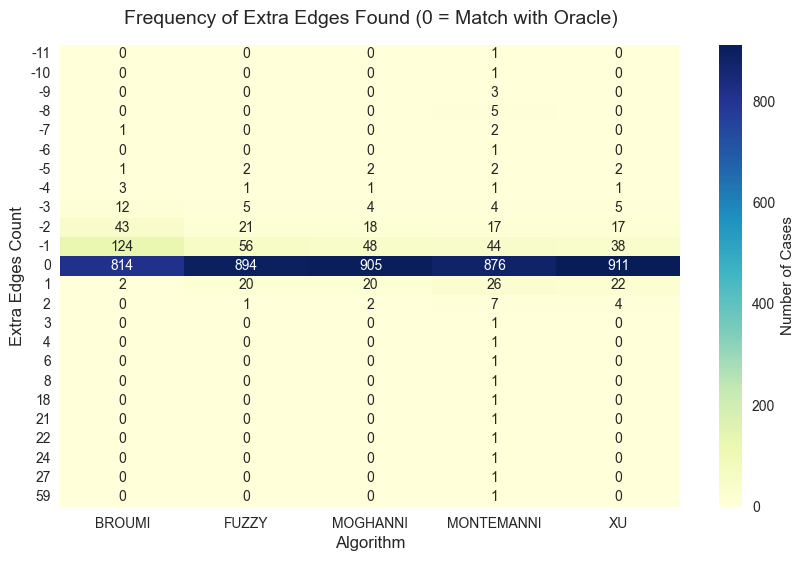

In [48]:
# 1. Calculate the difference in the number of edges
path_delta_df = pd.DataFrame()
oracle_path = 'oracle_ideal_path_length'

path_cols = [col for col in main_df.columns if 'path_length' in col and col != oracle_path]

for col in path_cols:
    # Capitalize algorithm name for professional look
    alg_name = col.replace('_path_length', '').upper()
    # Absolute difference: how many extra edges the algorithm added compared to Oracle
    path_delta_df[alg_name] = main_df[col] - main_df[oracle_path]

# 2. Visualization via Heatmap
plt.figure(figsize=(10, 6))

# Calculate counts of each delta value per algorithm
delta_counts = path_delta_df.apply(pd.Series.value_counts).fillna(0)

sns.heatmap(delta_counts, 
            annot=True, 
            fmt=".0f", 
            cmap="YlGnBu",
            cbar_kws={'label': 'Number of Cases'})

# English labels and title
plt.title("Frequency of Extra Edges Found (0 = Match with Oracle)", fontsize=14, pad=15)
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Extra Edges Count", fontsize=12)

plt.show()

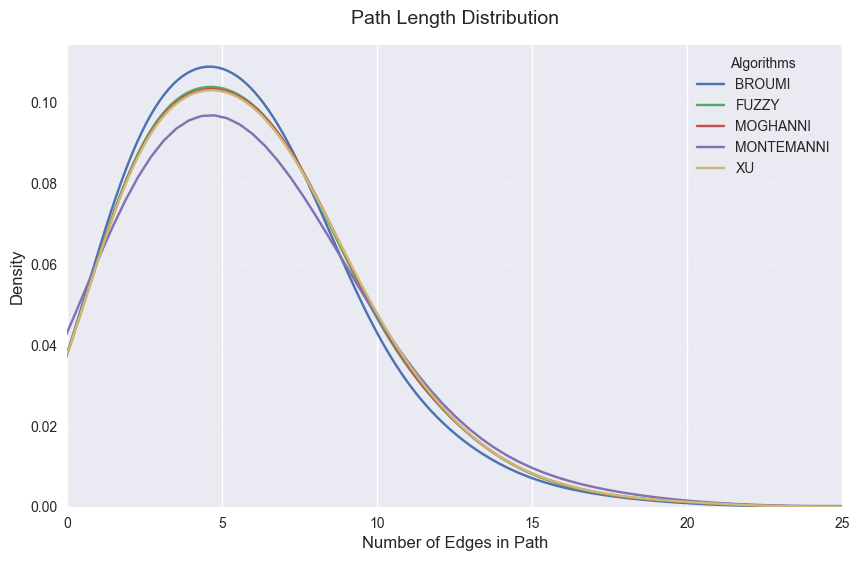

In [49]:
plt.figure(figsize=(10, 6))

for col in path_cols:
    # Clean the algorithm name and capitalize for the legend
    alg_name = col.replace('_path_length', '').upper()
    sns.kdeplot(main_df[col], label=alg_name, bw_adjust=2)

# Limit to 25 edges to ignore Montemanni's extreme anomalies
plt.xlim(0, 25) 

# English labels and title
plt.title("Path Length Distribution", fontsize=14, pad=15)
plt.xlabel("Number of Edges in Path", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.legend(title="Algorithms")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

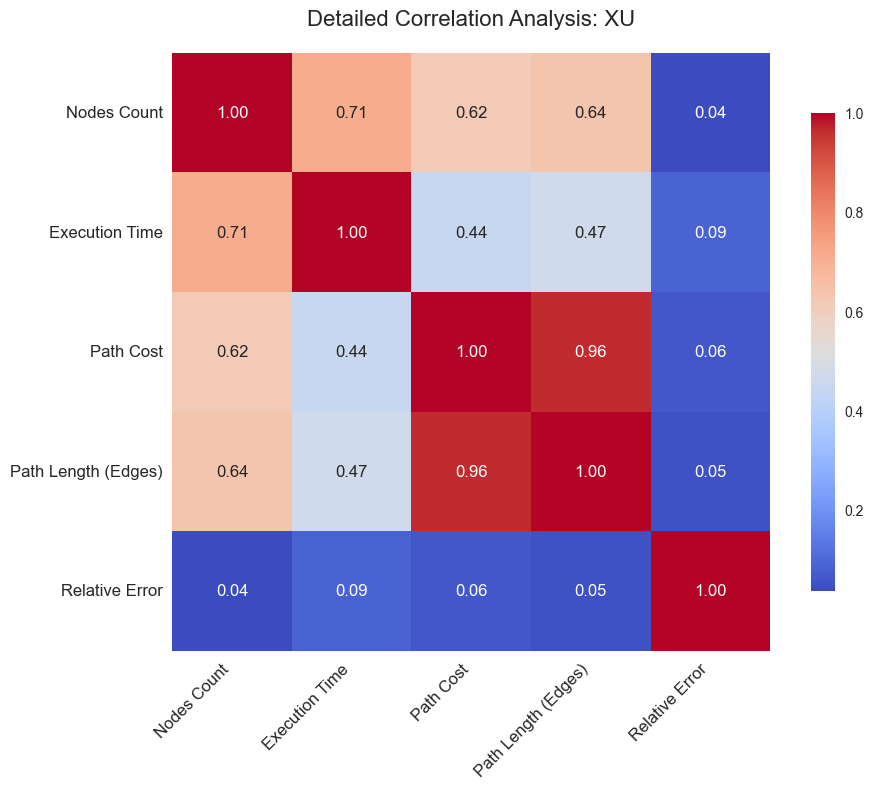

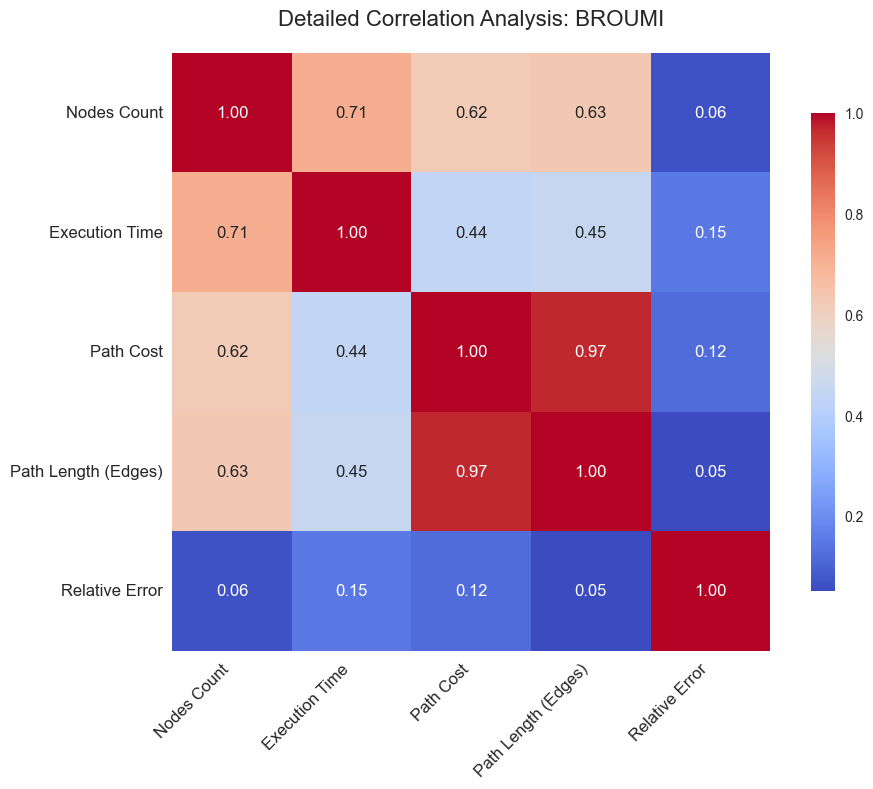

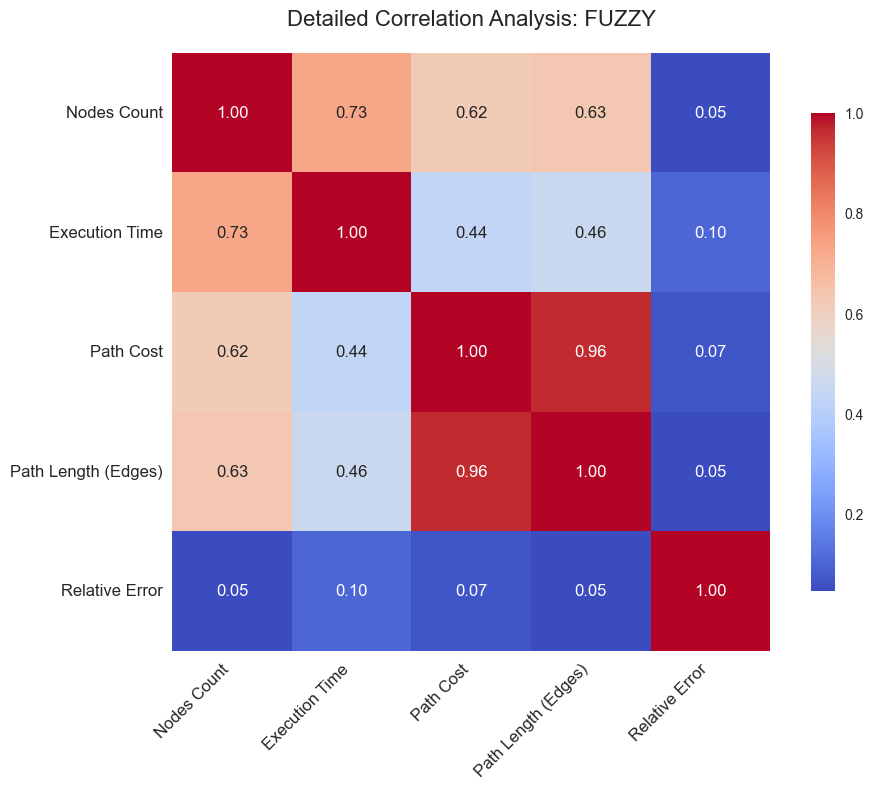

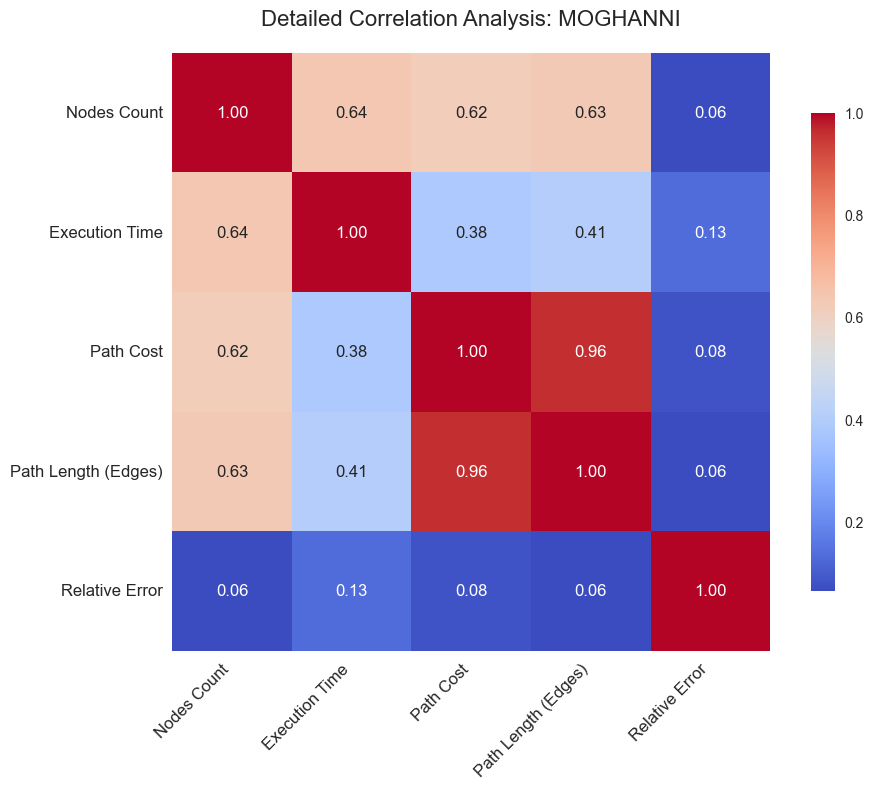

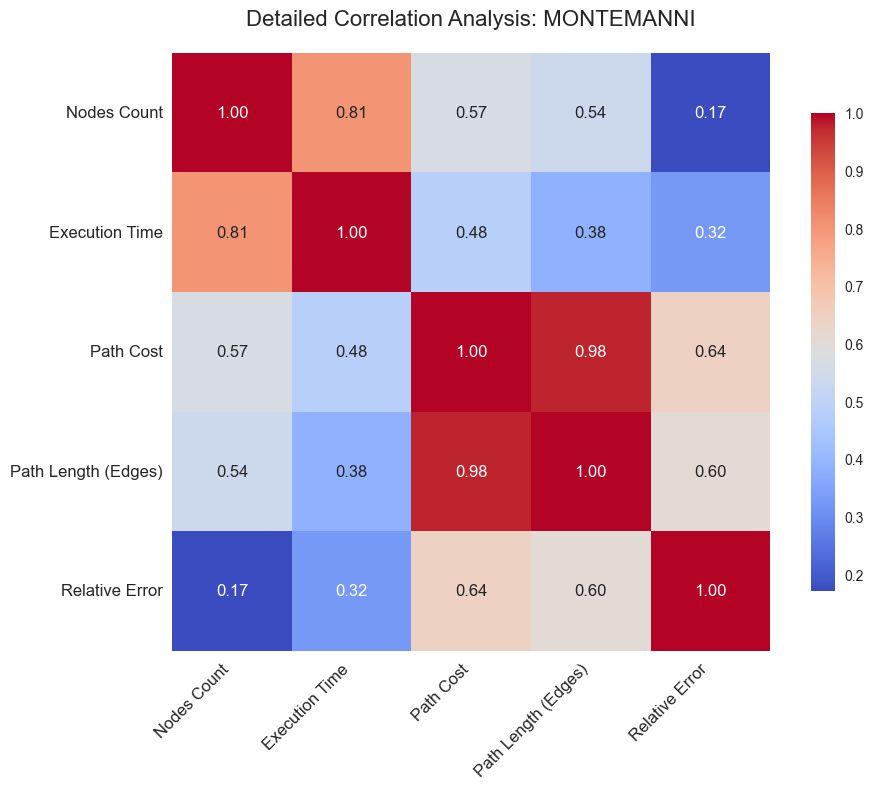

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

algorithms = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']

# Словарь для красивого перевода технических названий
label_mapping = {
    'oracle_num_nodes': 'Nodes Count',
    'time': 'Execution Time',
    'cost_real': 'Path Cost',
    'path_length': 'Path Length (Edges)',
    'error': 'Relative Error'
}

for alg in algorithms:
    # Собираем данные
    cols = ['oracle_num_nodes', f'{alg}_execution_time_ms', f'{alg}_cost_real', f'{alg}_path_length']
    existing_cols = [c for c in cols if c in main_df.columns]
    
    if existing_cols:
        temp_corr_data = main_df[existing_cols].copy()
        temp_corr_data[f'{alg}_error'] = error_df[alg]
        
        # Считаем корреляцию
        corr_matrix = temp_corr_data.corr()
        
        # Создаем фигуру
        plt.figure(figsize=(10, 8))
        
        # Очищаем названия колонок перед маппингом
        # Убираем префиксы алгоритмов и технические суффиксы
        clean_cols = [l.replace(f'{alg}_', '').replace('execution_', '').replace('_ms', '') for l in corr_matrix.columns]
        
        # Применяем английские названия из словаря
        english_labels = [label_mapping.get(l, l) for l in clean_cols]
        
        # Рисуем карту
        sns.heatmap(corr_matrix, 
                    annot=True, 
                    cmap='coolwarm', 
                    fmt=".2f", 
                    annot_kws={"size": 12},
                    square=True, 
                    cbar_kws={"shrink": .8},
                    xticklabels=english_labels,
                    yticklabels=english_labels)
        
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(rotation=0, fontsize=12)
        
        # Заголовок на английском
        plt.title(f"Detailed Correlation Analysis: {alg.upper()}", fontsize=16, pad=20)
        
        plt.tight_layout()
        plt.show()

In [51]:
import numpy as np
import pandas as pd

# List of algorithms
algs = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']
summary_stats = []

for alg in algs:
    # 1. Hits and Errors
    # Calculate cases where the relative error is effectively 0
    exact_hits = (error_df[alg].abs() < 1e-6).sum()
    hit_rate = (exact_hits / len(error_df)) * 100
    
    # Exclude infinities (inf) for calculating averages
    clean_errors = error_df[alg].replace([np.inf, -np.inf], np.nan).dropna()
    avg_miss_err = clean_errors[clean_errors > 1e-6].mean() * 100
    max_err = clean_errors.max() * 100
    
    # 2. Structural Accuracy (Path by edges)
    # Check how often the path length matched the Oracle's ideal path length
    struct_hits = (main_df[f'{alg}_path_length'] == main_df['oracle_ideal_path_length']).sum()
    struct_acc = (struct_hits / len(main_df)) * 100
    
    # 3. Efficiency (Microseconds per Node)
    # Convert ms to microseconds (*1000) and divide by the number of nodes
    time_per_node = (main_df[f'{alg}_execution_time_ms'] * 1000 / main_df['oracle_num_nodes']).mean()
    
    summary_stats.append({
        'Algorithm': alg.upper(),
        'Exact Hits (%)': round(hit_rate, 2),
        'Avg Error on Miss (%)': round(avg_miss_err, 2),
        'Max Error (%)': round(max_err, 2),
        'Edge Match Rate (%)': round(struct_acc, 2),
        'Time per Node (µs/node)': round(time_per_node, 3)
    })

# Create and display the final summary table
full_stats_df = pd.DataFrame(summary_stats).set_index('Algorithm')

print("--- Final Algorithm Performance Summary ---")
display(full_stats_df)

--- Final Algorithm Performance Summary ---


,Exact Hits (%),Avg Error on Miss (%),Max Error (%),Edge Match Rate (%),Time per Node (µs/node)
Algorithm,,,,,
XU,86.3,6.36,27.67,91.1,0.597
BROUMI,76.5,12.07,85.71,81.4,0.915
FUZZY,84.3,6.85,43.75,89.4,0.862
MOGHANNI,85.5,6.24,31.77,90.5,1.255
MONTEMANNI,81.4,22.04,654.72,87.6,295.703


In [52]:
import numpy as np
import pandas as pd

# 1. Create a filter: keep only graphs where the number of nodes is < 1000
mask = main_df['oracle_num_nodes'] < 1000

# Filter main dataframes once for convenience
df_filtered = main_df[mask].copy()
errors_filtered = error_df[mask].copy()

algs = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']
summary_stats = []

for alg in algs:
    # Use only the filtered data
    current_errors = errors_filtered[alg]
    
    # 1. Hits and Errors
    # Count cases where relative error is effectively zero
    exact_hits = (current_errors.abs() < 1e-6).sum()
    hit_rate = (exact_hits / len(current_errors)) * 100
    
    # Exclude infinities (inf) for calculating averages
    clean_errors = current_errors.replace([np.inf, -np.inf], np.nan).dropna()
    avg_miss_err = clean_errors[clean_errors > 1e-6].mean() * 100
    max_err = clean_errors.max() * 100
    
    # 2. Structural Accuracy (Path by edges)
    # Check how often path length matched the Oracle's ideal path length
    struct_hits = (df_filtered[f'{alg}_path_length'] == df_filtered['oracle_ideal_path_length']).sum()
    struct_acc = (struct_hits / len(df_filtered)) * 100
    
    # 3. Efficiency (Microseconds per node)
    # Convert ms to microseconds (*1000) and divide by node count
    time_per_node = (df_filtered[f'{alg}_execution_time_ms'] * 1000 / df_filtered['oracle_num_nodes']).mean()
    
    summary_stats.append({
        'Algorithm': alg.upper(),
        'Exact Hits (%)': round(hit_rate, 2),
        'Avg Error on Miss (%)': round(avg_miss_err, 2),
        'Max Error (%)': round(max_err, 2),
        'Edge Match Rate (%)': round(struct_acc, 2),
        'Time per Node (µs/node)': round(time_per_node, 3)
    })

# Output the result
full_stats_df_small = pd.DataFrame(summary_stats).set_index('Algorithm')
print(f"Statistics for graphs under 1000 nodes (Total tasks: {len(df_filtered)}):")
display(full_stats_df_small)

Statistics for graphs under 1000 nodes (Total tasks: 599):


,Exact Hits (%),Avg Error on Miss (%),Max Error (%),Edge Match Rate (%),Time per Node (µs/node)
Algorithm,,,,,
XU,89.65,8.22,27.67,94.49,0.599
BROUMI,82.64,14.42,85.71,88.48,0.863
FUZZY,88.31,8.29,43.75,93.66,0.761
MOGHANNI,89.32,7.37,27.43,94.32,1.154
MONTEMANNI,86.64,7.87,34.50,92.82,180.672
